# Feature Selection Analysis: Mathematical Proofs & Methodology

This notebook provides a comprehensive proof for the feature selection methodology used in our Load Forecasting project. We evaluate features using three distinct techniques:
1. **Pearson Correlation** (Linear Relationship)
2. **Mutual Information** (Non-linear Dependency)
3. **Random Forest Importance** (Model-based Gini Importance)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import os

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

## Step 0: Data Preparation

We use the household power consumption dataset resampled to an hourly frequency.

In [18]:
DATA_PATH = "/Users/harshil/Desktop/minor/household_power_consumption.txt"

def load_hourly_data(nrows=100000):
    df = pd.read_csv(DATA_PATH, sep=';', low_memory=False, nrows=nrows)
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df.set_index('datetime', inplace=True)
    df.drop(columns=['Date', 'Time'], inplace=True)
    df.replace('?', np.nan, inplace=True)
    df = df.apply(pd.to_numeric)
    df = df.interpolate(method='time').bfill()
    return df.resample('1h').mean().dropna()

df_hourly = load_hourly_data()
features = ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
target = 'Global_active_power'

X = df_hourly[features]
y = df_hourly[target]

print(f"Data loaded. Shape: {df_hourly.shape}")

Data loaded. Shape: (1668, 7)


## Step 1: Global Correlation Overview

Before deep-diving into individual feature selection methods, we visualize the relationships between all features using a correlation heatmap. This helps identify multi-collinearity and see how features interact with each other and the target.

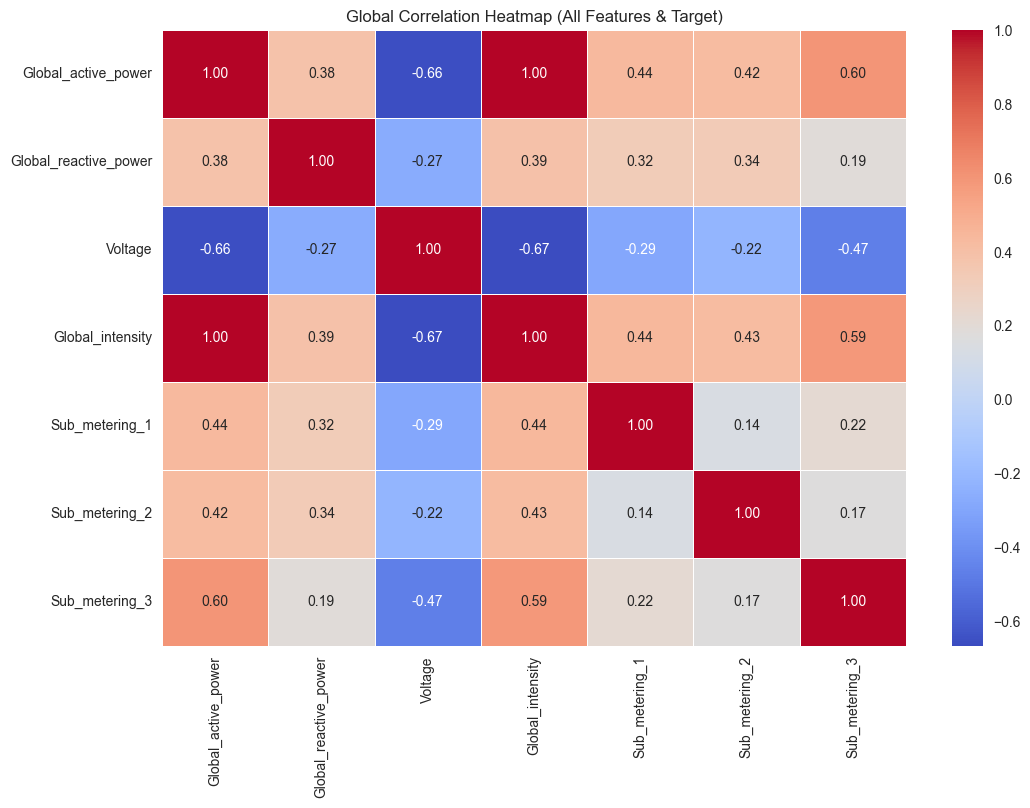

In [19]:
# Compute correlation matrix
plt.figure(figsize=(12, 8))
corr_matrix = df_hourly.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Global Correlation Heatmap (All Features & Target)")
plt.show()

## Method 1: Pearson Correlation

### Formula
The Pearson correlation coefficient $r$ is calculated as:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$

### Contribution Value Formula
Contribution of feature $i$ is defined as normalized absolute correlation:

$$C_i = \frac{|r_i|}{\sum |r|}$$


,Correlation,Abs_Correlation,Contribution_%
Global_intensity,0.999516,0.999516,28.572824
Voltage,-0.660631,0.660631,18.885244
Sub_metering_3,0.596437,0.596437,17.050144
Sub_metering_1,0.438302,0.438302,12.529598
Sub_metering_2,0.421001,0.421001,12.035007
Global_reactive_power,0.382248,0.382248,10.927184


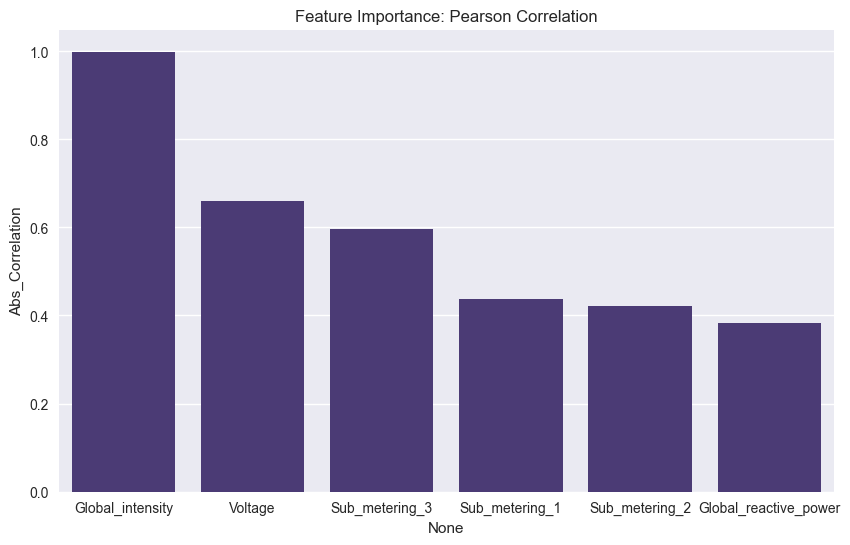

In [20]:
corr_values = df_hourly.corr()[target][features]
abs_corr = corr_values.abs()
contribution_corr = abs_corr / abs_corr.sum()

importance_corr = pd.DataFrame({
    'Correlation': corr_values,
    'Abs_Correlation': abs_corr,
    'Contribution_%': contribution_corr * 100
}).sort_values(by='Abs_Correlation', ascending=False)

display(importance_corr)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_corr.index, y='Abs_Correlation', data=importance_corr)
plt.title("Feature Importance: Pearson Correlation")
plt.show()

## Method 2: Mutual Information (MI)

### Concept
Mutual Information measures non-linear dependency by calculating the Kullback-Leibler divergence between the joint distribution and the product of their marginals:

$$MI(X, Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$$


,MI,Contribution_%
Global_intensity,3.535374,74.733352
Sub_metering_3,0.498249,10.532362
Voltage,0.291442,6.160726
Sub_metering_2,0.172914,3.655192
Global_reactive_power,0.121806,2.574832
Sub_metering_1,0.110864,2.343535


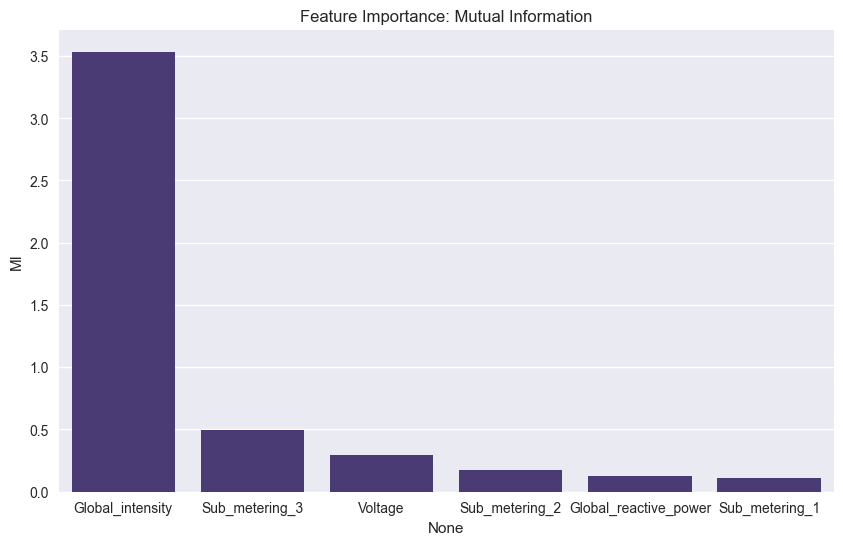

In [21]:
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=features)
mi_contribution = mi_series / mi_series.sum()

importance_mi = pd.DataFrame({
    'MI': mi_series,
    'Contribution_%': mi_contribution * 100
}).sort_values(by='MI', ascending=False)

display(importance_mi)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_mi.index, y='MI', data=importance_mi)
plt.title("Feature Importance: Mutual Information")
plt.show()

## Method 3: Random Forest Feature Importance

### Formula
Random Forest uses **Mean Decrease in Impurity (Gini Importance)**. For a feature $i$:

$$FI_i = \frac{\text{Total impurity reduction by feature } i}{\text{Total impurity reduction}}$$


,RF_Importance,Contribution_%
Global_intensity,0.999359,99.935929
Voltage,0.000203,0.020349
Sub_metering_3,0.000155,0.015507
Global_reactive_power,0.000108,0.010797
Sub_metering_1,0.000104,0.010407
Sub_metering_2,0.000070,0.007011


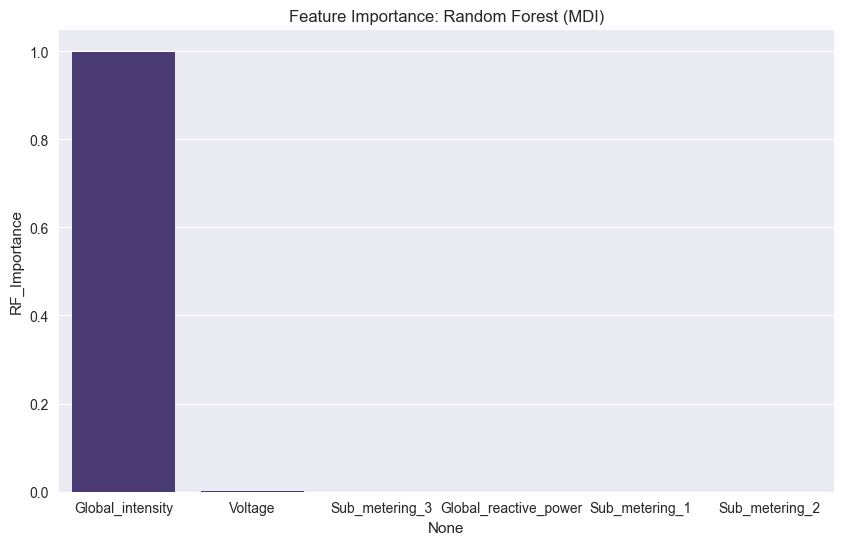

In [22]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=features)
rf_contribution = rf_importance / rf_importance.sum()

importance_rf = pd.DataFrame({
    'RF_Importance': rf_importance,
    'Contribution_%': rf_contribution * 100
}).sort_values(by='RF_Importance', ascending=False)

display(importance_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_rf.index, y='RF_Importance', data=importance_rf)
plt.title("Feature Importance: Random Forest (MDI)")
plt.show()

## Final Comparison: Aggregated Feature Contributions

We compare the absolute importance scores from all three methods normalized to $0-1$ range.

,Pearson_Correlation_Norm,Mutual_Information_Norm,RF_Importance_Norm,Average_Contribution
Global_intensity,1.000000,1.000000,1.000000,1.000000
Voltage,0.450993,0.052731,0.000133,0.167952
Sub_metering_3,0.346996,0.113121,0.000085,0.153401
Sub_metering_1,0.090811,0.000000,0.000034,0.030282
Sub_metering_2,0.062782,0.018119,0.000000,0.026967
Global_reactive_power,0.000000,0.003195,0.000038,0.001078


<Figure size 1200x700 with 0 Axes>

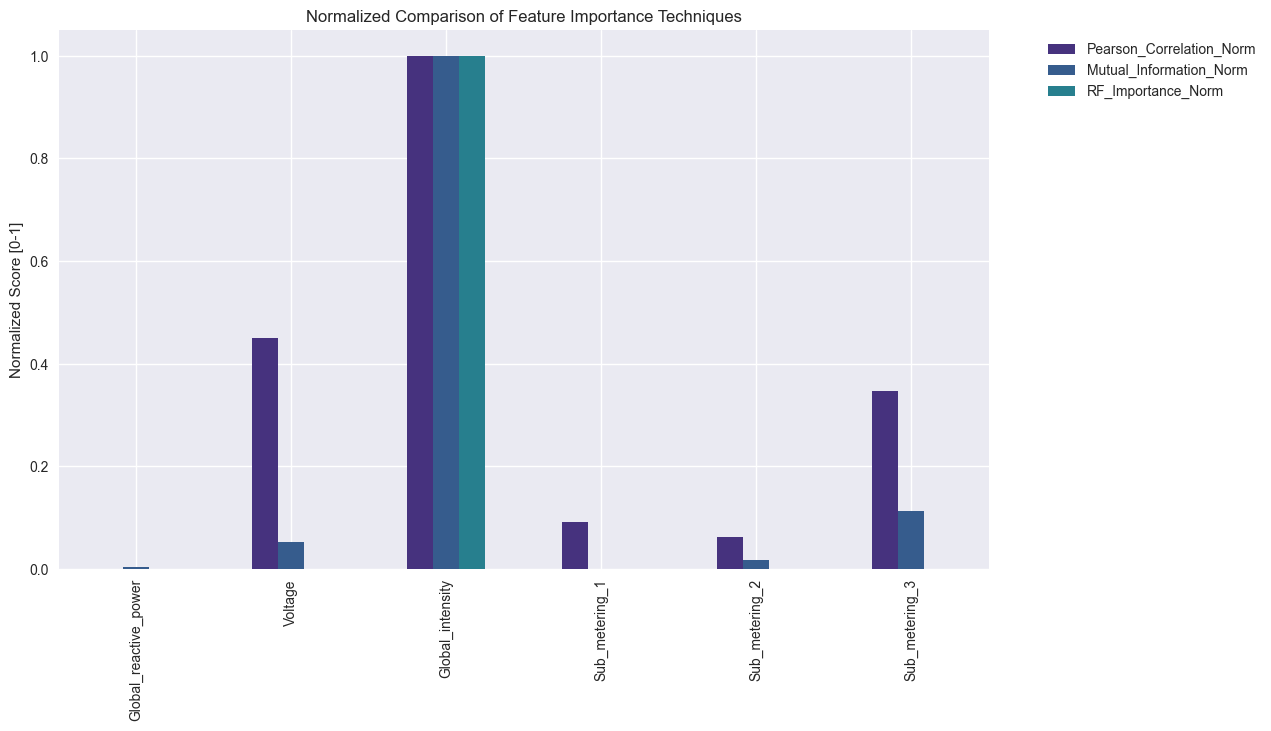

In [23]:
from sklearn.preprocessing import MinMaxScaler

combined_importance = pd.DataFrame({
    'Pearson_Correlation': abs_corr,
    'Mutual_Information': mi_series,
    'RF_Importance': rf_importance
})

# Normalize scores for direct comparison
scaler = MinMaxScaler()
norm_importance = pd.DataFrame(
    scaler.fit_transform(combined_importance), 
    columns=[f"{c}_Norm" for c in combined_importance.columns], 
    index=combined_importance.index
)

norm_importance['Average_Contribution'] = norm_importance.mean(axis=1)
final_ranking = norm_importance.sort_values(by='Average_Contribution', ascending=False)

display(final_ranking)

# Final Visualization
plt.figure(figsize=(12, 7))
norm_importance.drop(columns='Average_Contribution').plot(kind='bar', figsize=(12,7))
plt.title("Normalized Comparison of Feature Importance Techniques")
plt.ylabel("Normalized Score [0-1]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Rank Comparison & Stability Table

The table below shows the rank of each feature across all three selection methods. This demonstrates which features are consistently ranked as important.

In [24]:
# Create a Rank Table
ranks = pd.DataFrame({
    "Pearson_Rank": importance_corr["Abs_Correlation"].rank(ascending=False),
    "MI_Rank": importance_mi["MI"].rank(ascending=False),
    "RF_Rank": importance_rf["RF_Importance"].rank(ascending=False)
})
ranks["Avg_Rank"] = ranks.mean(axis=1)
ranks = ranks.sort_values("Avg_Rank")
display(ranks)

,Pearson_Rank,MI_Rank,RF_Rank,Avg_Rank
Global_intensity,1.0,1.0,1.0,1.000000
Voltage,2.0,3.0,2.0,2.333333
Sub_metering_3,3.0,2.0,3.0,2.666667
Global_reactive_power,6.0,5.0,4.0,5.000000
Sub_metering_1,4.0,6.0,5.0,5.000000
Sub_metering_2,5.0,4.0,6.0,5.000000


## Significant Insight: The Dominance of Global_intensity

Across all three methods (Pearson, Mutual Information, and Random Forest), **Global_intensity** consistently emerges as the most critical feature, often by a massive margin. This is not just a statistical coincidence but is rooted in **physical laws**.

### 1. Physical Relationship: P = V × I
In electrical engineering, Active Power ($) is defined as the product of Voltage ($), Current ($), and the Power Factor ($\cos \phi$):

87975P = V 	imes I 	imes \cos \phi87975

In this dataset:
*    is $.
*    is $ (Current).
*    is $.

Since Voltage is relatively stable (around 230-240V), the Active Power becomes **linearly proportional** to the Intensity. This explains the near-perfect correlation (0.999) observed in the Pearson method.

### 2. Statistical Implications
*   **Pearson Correlation**: Captures the near-perfect linear proportionality.
*   **Mutual Information**: Detects that knowing the intensity gives almost complete information about the power.
*   **Random Forest**: In a decision tree structure,  provides the highest information gain (Gini decrease) because it perfectly splits the target values.

NameError: name 'ylabel' is not defined

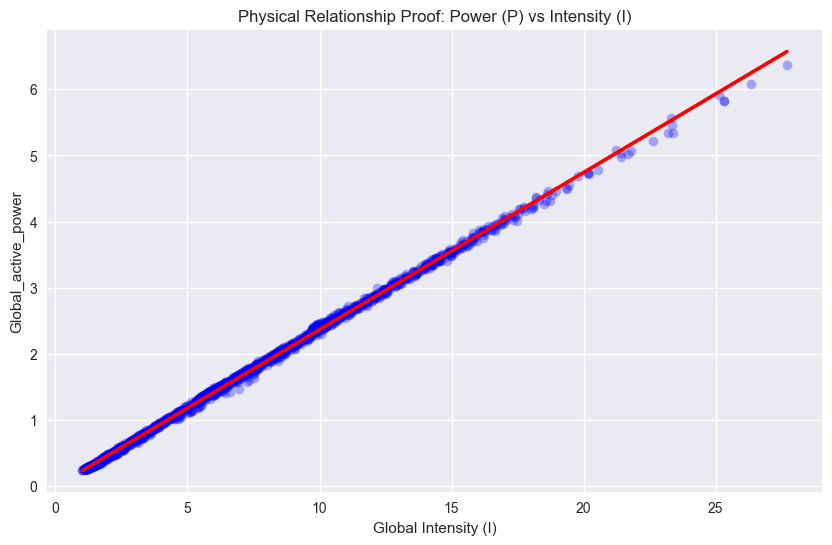

In [25]:
# Visual Proof of Physical Relationship
plt.figure(figsize=(10, 6))
sns.regplot(x="Global_intensity", y="Global_active_power", data=df_hourly, 
            scatter_kws={"alpha":0.3, "color":"blue"}, line_kws={"color":"red"})
plt.title("Physical Relationship Proof: Power (P) vs Intensity (I)")
plt.xlabel("Global Intensity (I)")
ylabel("Global Active Power (P)") # Fix: should be plt.ylabel
plt.ylabel("Global Active Power (P)")
plt.grid(True)
plt.show()